In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt


# 1- Préparation des données

In [38]:
# Charger les données
df=pd.read_csv("data/Customer-Churn.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [39]:
# Dimensions
print(f"Lignes : {df.shape[0]}")
print(f"Colonnes : {df.shape[1]}")

# Types des variables
df.info()


Lignes : 7043
Colonnes : 21
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 no

-Nous remarquons que la colonne TotalCharges constitue des nombres mais est typé comme un caractère, nous allons changer cela

In [40]:
#onversion en numérique
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


In [41]:
# Statistiques descriptives pour les variables numériques
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [42]:
# Statistiques descriptives pour les variables catégorielles
df.describe(include="object")

C:\Users\Amatek\AppData\Local\Temp\ipykernel_23208\3009522313.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [43]:
# Vérification des valeurs manquantes
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [44]:
#Voyons les lignes avec des valeurs manquantes
df[df["TotalCharges"].isna()].head(11)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [45]:
# Pour traiter ces valeurs manquantes, on les remplace par la médiane
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
df.isnull().sum() 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [46]:
#la variable CostomerID n'est pas utile pour notre analyse, on peut la supprimer    
df.drop("customerID", axis=1, inplace=True)

In [47]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [48]:
#Distribution de la variable cible
df["Churn"].value_counts(normalize=True) * 100


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [50]:
#Separation des variables catégorielles et numériques
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(exclude="object").columns

print("Variables catégorielles :", list(cat_cols))
print("Variables numériques :", list(num_cols))


Variables catégorielles : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Variables numériques : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


C:\Users\Amatek\AppData\Local\Temp\ipykernel_23208\3978724761.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


### Analyse exploratoire des données

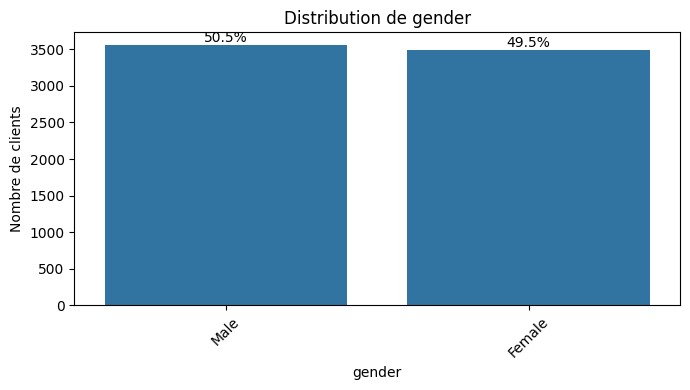

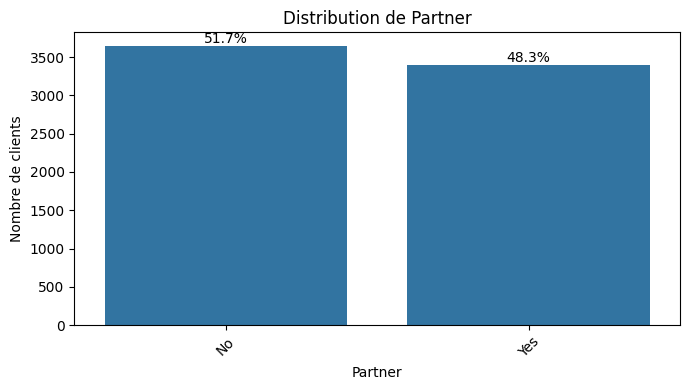

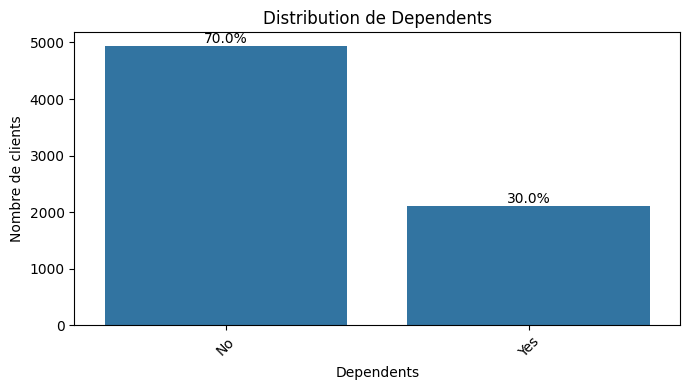

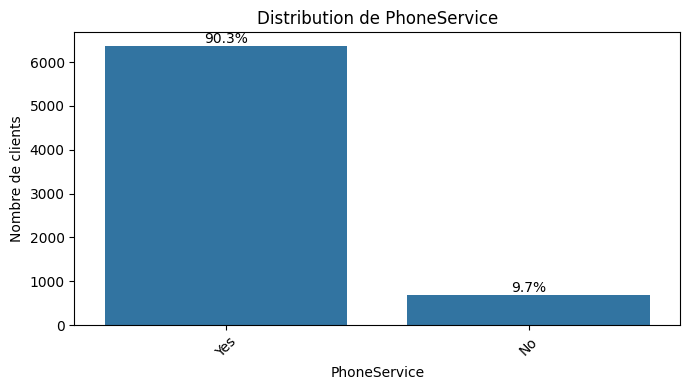

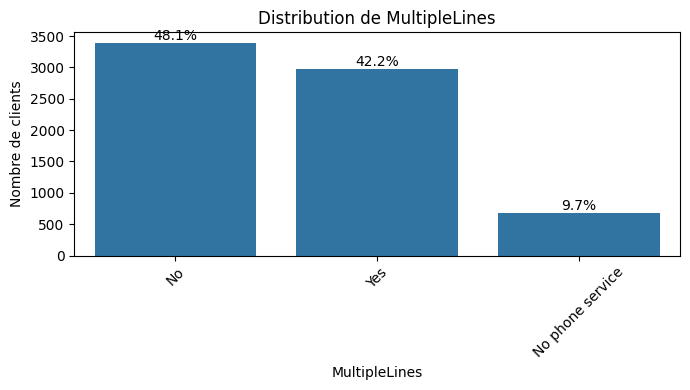

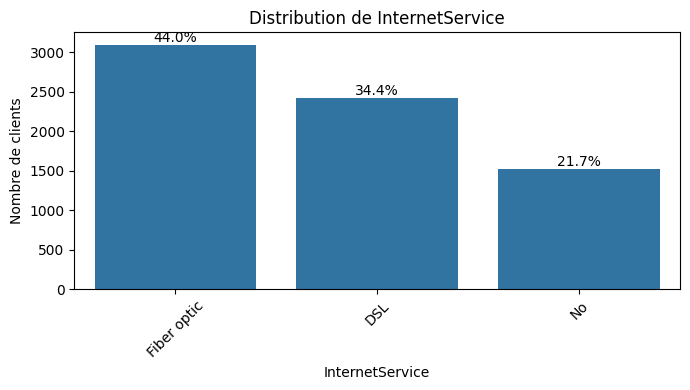

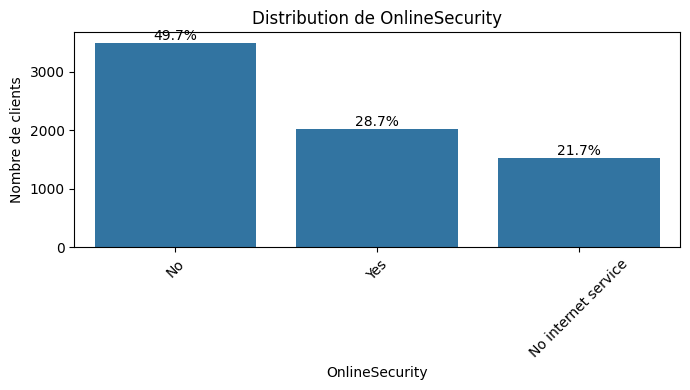

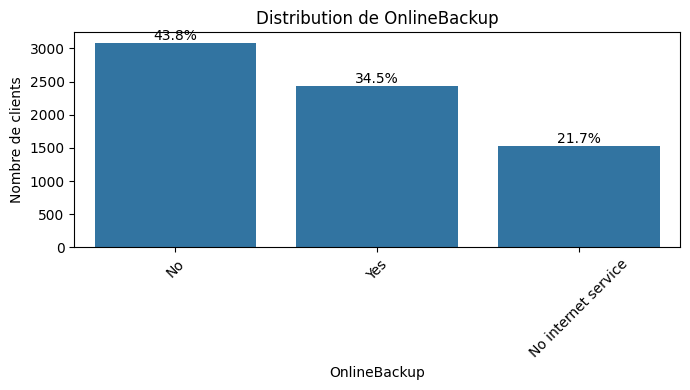

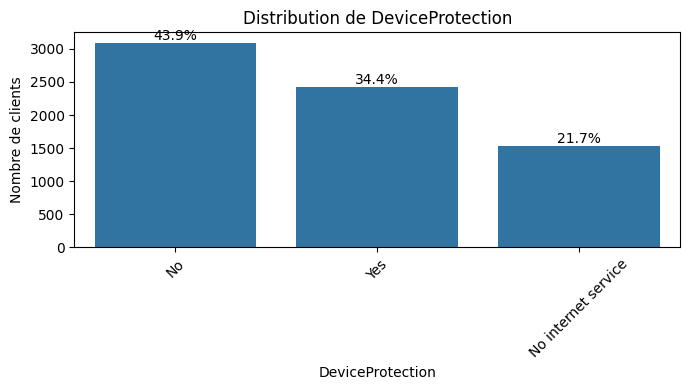

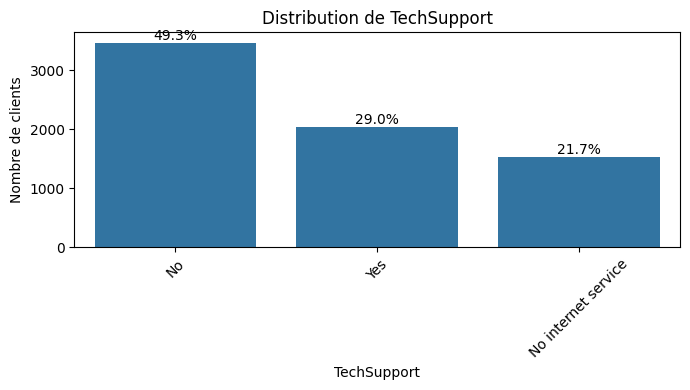

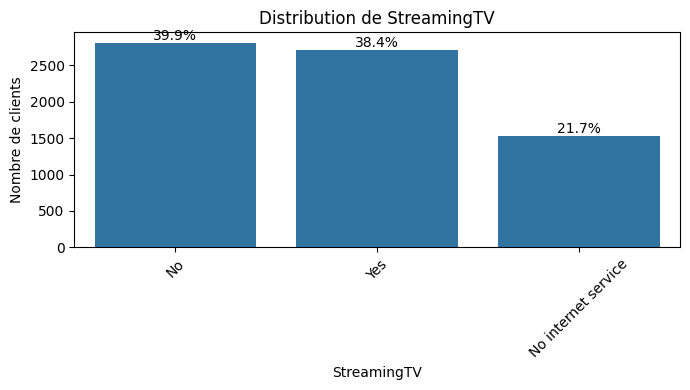

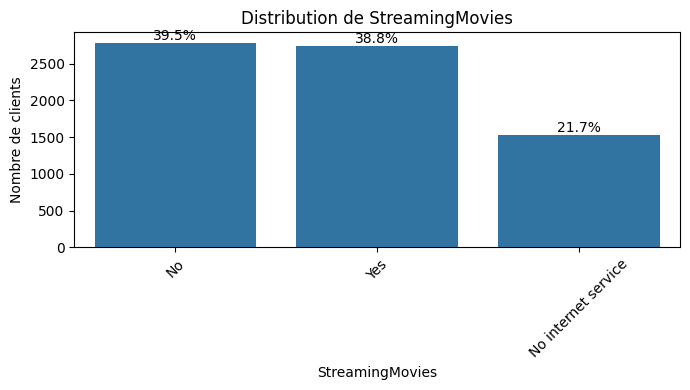

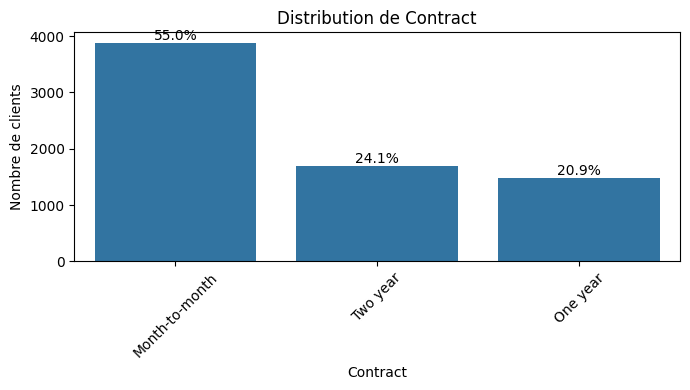

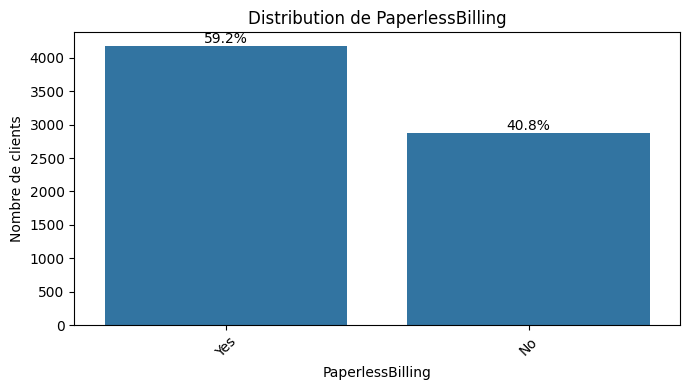

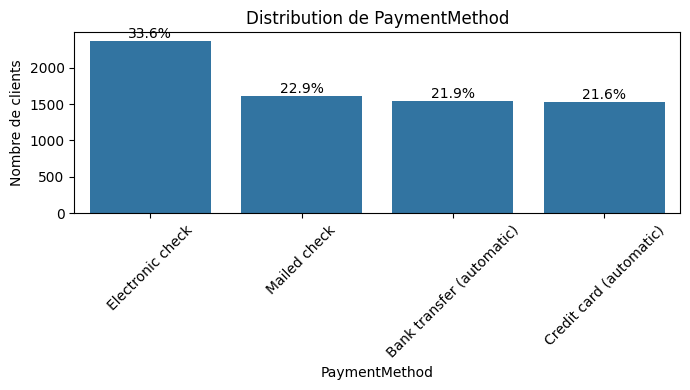

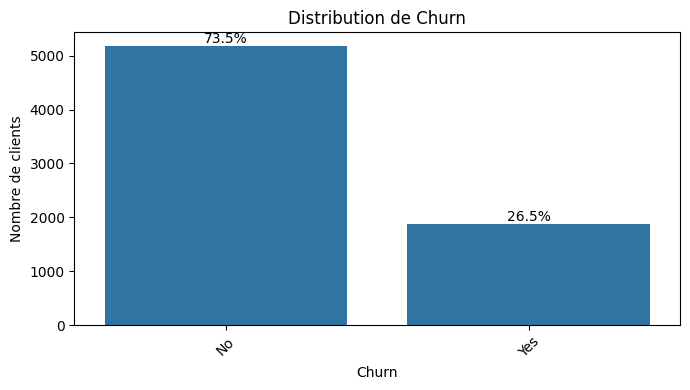

In [51]:
#Voyons maintenant la distribution de chaque variable catégorielle

def plot_categorical_distribution(df, column):
    """
    Affiche la distribution d'une variable catégorielle
    avec le pourcentage de chaque catégorie.
    """
    # Calcul des pourcentages
    value_counts = df[column].value_counts(normalize=True) * 100
    order = value_counts.index

    plt.figure(figsize=(7, 4))
    ax = sns.countplot(data=df, x=column, order=order)

    plt.title(f"Distribution de {column}")
    plt.xlabel(column)
    plt.ylabel("Nombre de clients")

    # Ajout des pourcentages sur le graphe
    for p in ax.patches:
        height = p.get_height()
        percentage = height / len(df) * 100
        ax.annotate(f"{percentage:.1f}%",
                    (p.get_x() + p.get_width() / 2, height),
                    ha="center", va="bottom", fontsize=10)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    plot_categorical_distribution(df, col)

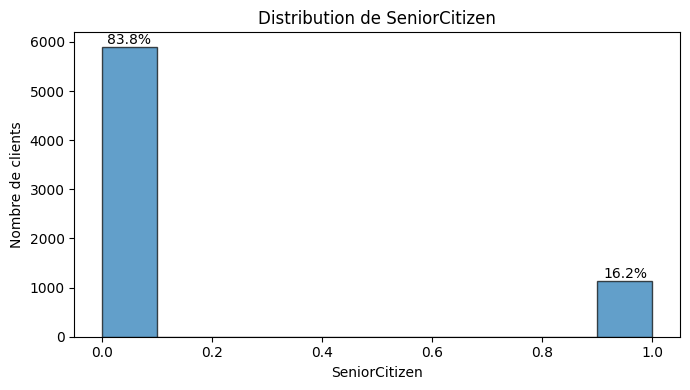

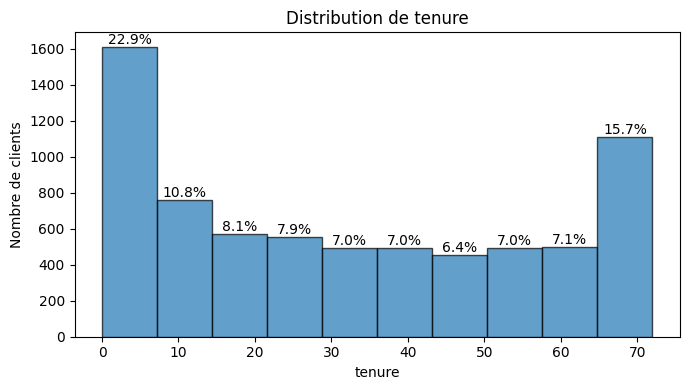

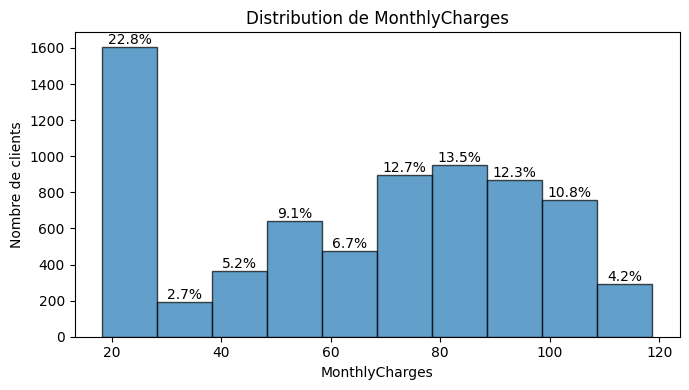

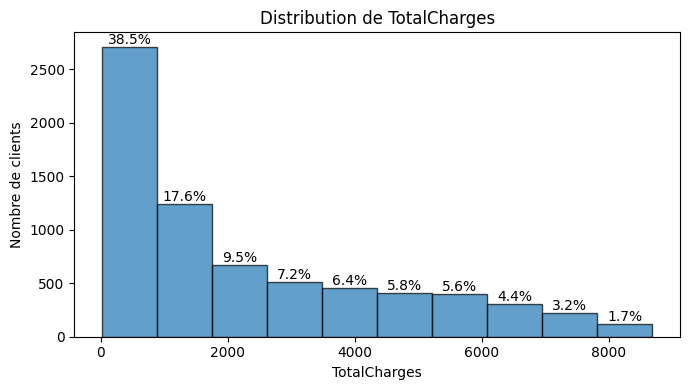

In [52]:
#Voyons maintenant la distribution de chaque variable numérique
def plot_numeric_distribution(df, column, bins=10):
    """
    Affiche la distribution d'une variable numérique
    avec le pourcentage par intervalle (bin).
    """
    data = df[column].dropna()

    counts, bin_edges = np.histogram(data, bins=bins)
    percentages = counts / counts.sum() * 100
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    plt.figure(figsize=(7, 4))
    plt.hist(data, bins=bins, edgecolor="black", alpha=0.7)

    plt.title(f"Distribution de {column}")
    plt.xlabel(column)
    plt.ylabel("Nombre de clients")

    # Ajouter les pourcentages au-dessus de chaque barre
    for count, percentage, x in zip(counts, percentages, bin_centers):
        if count > 0:
            plt.text(x, count, f"{percentage:.1f}%",
                     ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()
for col in num_cols:
    plot_numeric_distribution(df, col, bins=10)

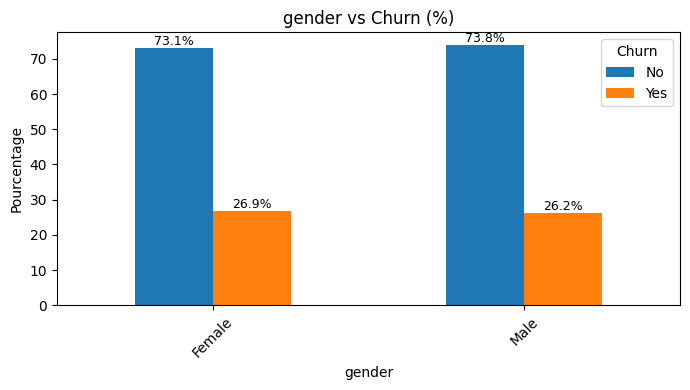

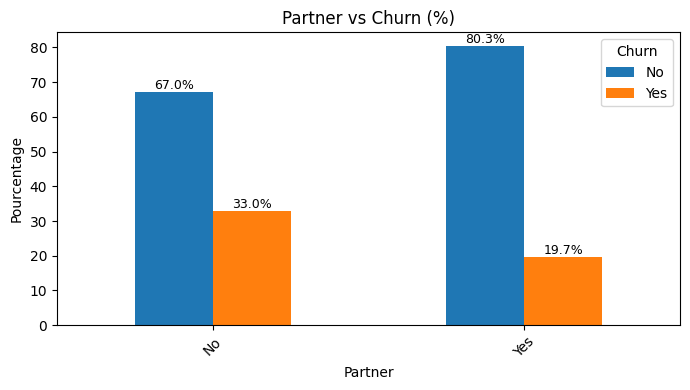

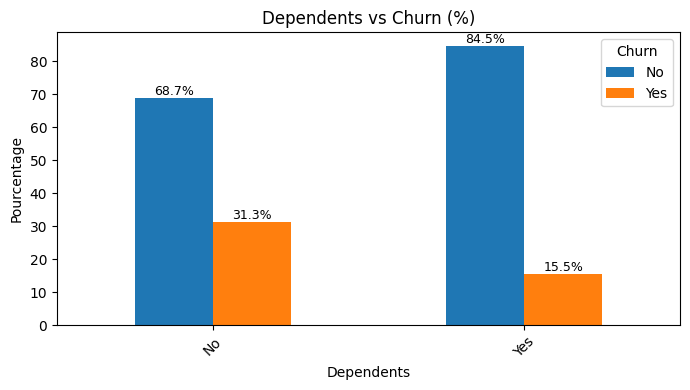

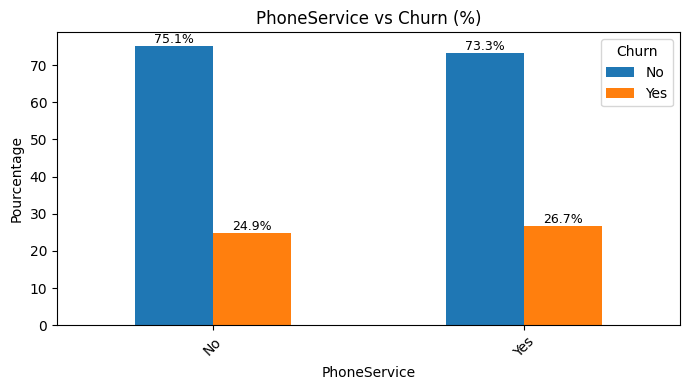

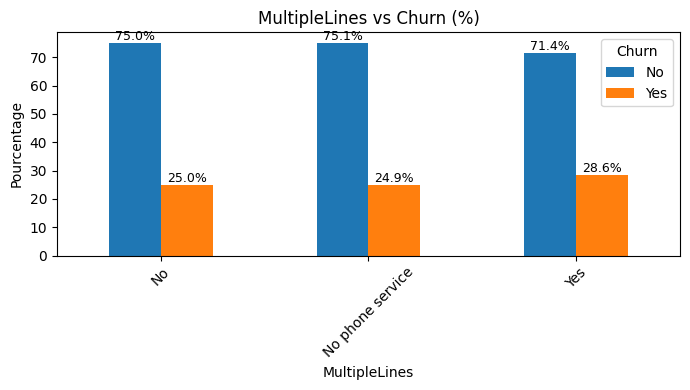

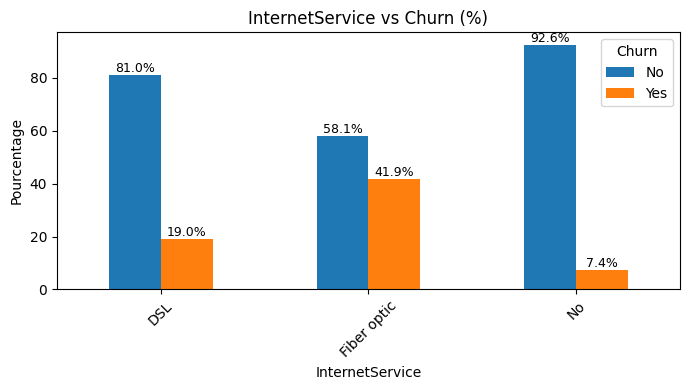

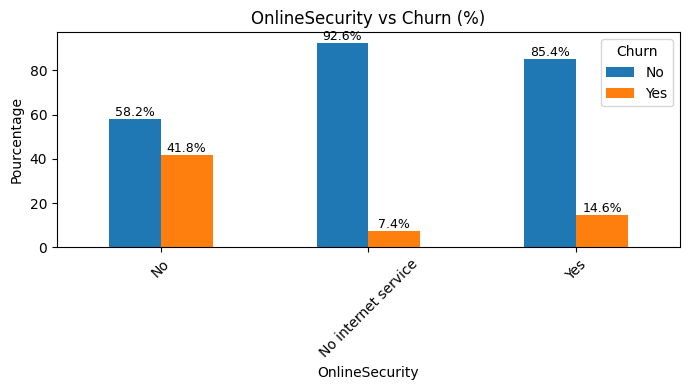

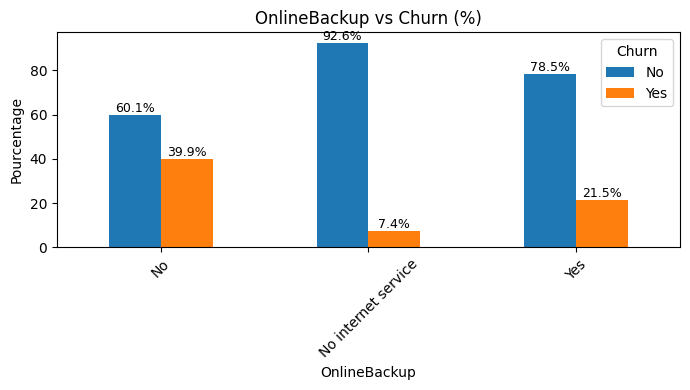

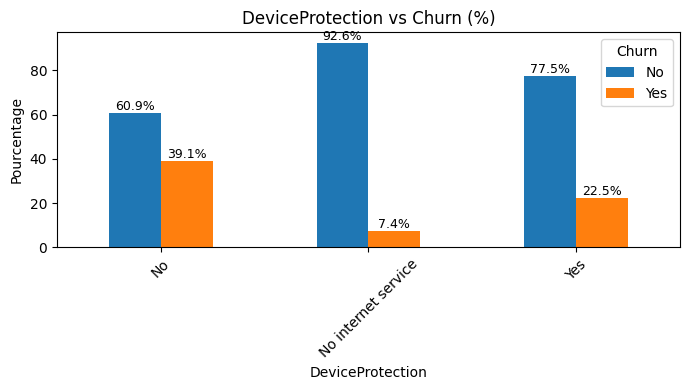

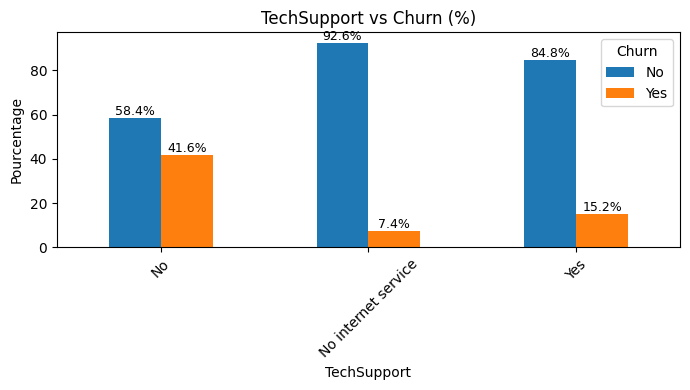

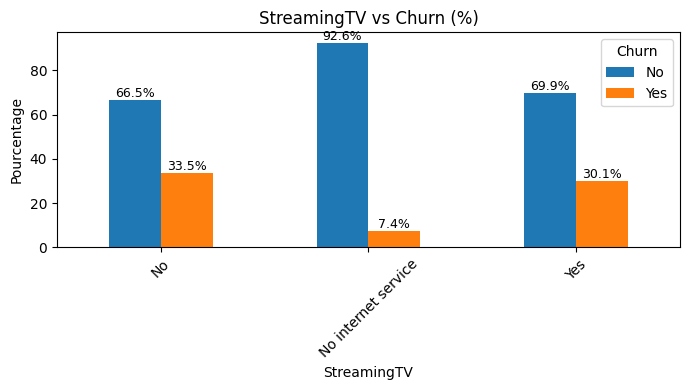

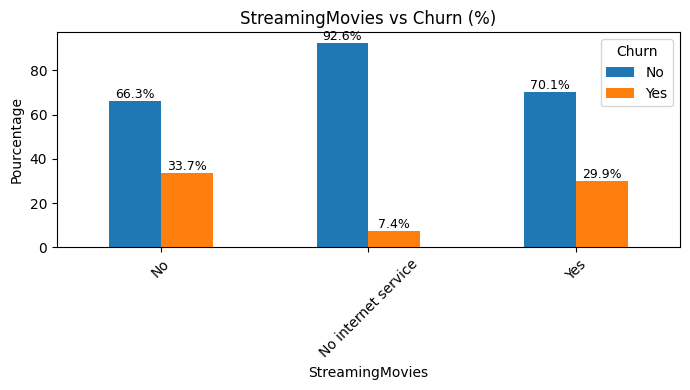

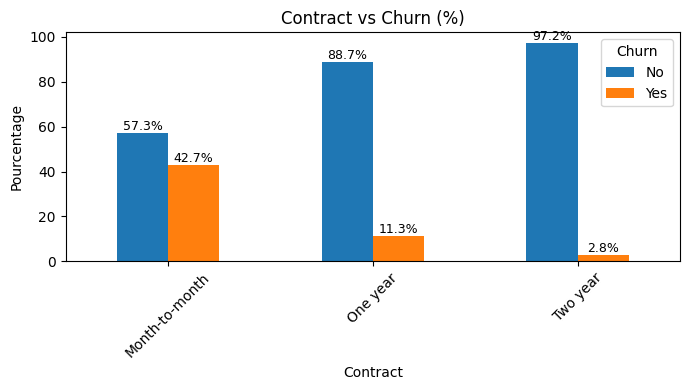

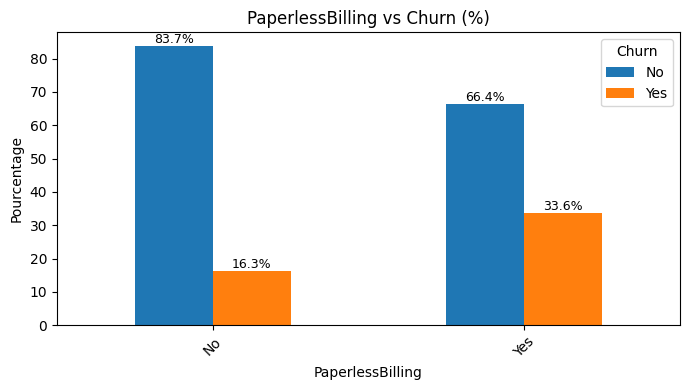

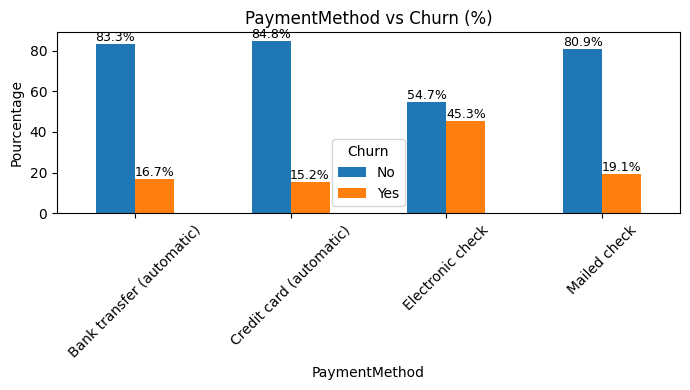

In [54]:
#Analysons maintenant la relation entre les variables catégorielles et la variable cible Churn
def plot_categorical_vs_churn(df, col):
    """
    Affiche la distribution d'une variable catégorielle
    par rapport à Churn (en pourcentage).
    """
    # Tableau de contingence
    contingency = pd.crosstab(df[col], df["Churn"], normalize="index") * 100

    ax = contingency.plot(kind="bar", figsize=(7,4))

    plt.title(f"{col} vs Churn (%)")
    plt.ylabel("Pourcentage")
    plt.xlabel(col)
    plt.legend(title="Churn")
    plt.xticks(rotation=45)

    # Affichage des pourcentages
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", label_type="edge", fontsize=9)

    plt.tight_layout()
    plt.show()

cat_cols = [col for col in cat_cols if col not in ["Churn"]]

for col in cat_cols:
    plot_categorical_vs_churn(df, col)

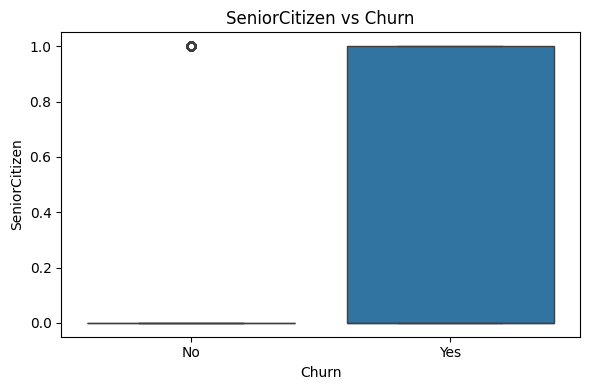

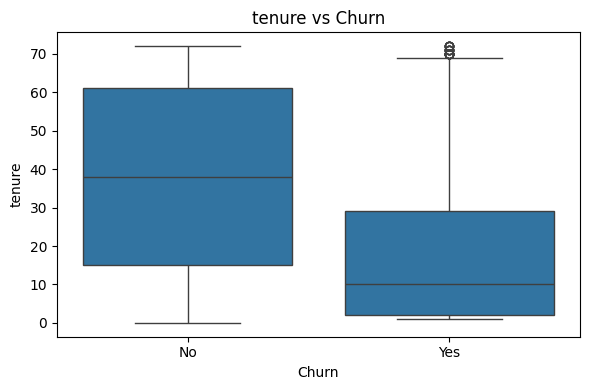

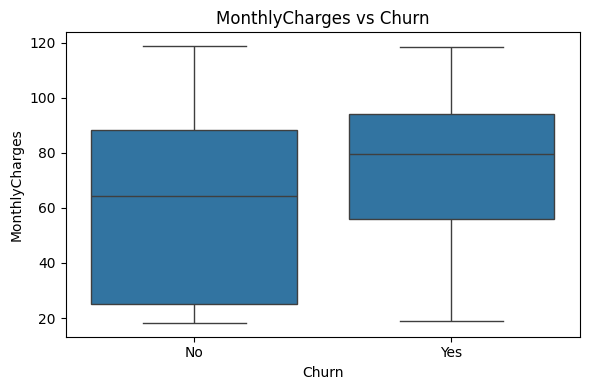

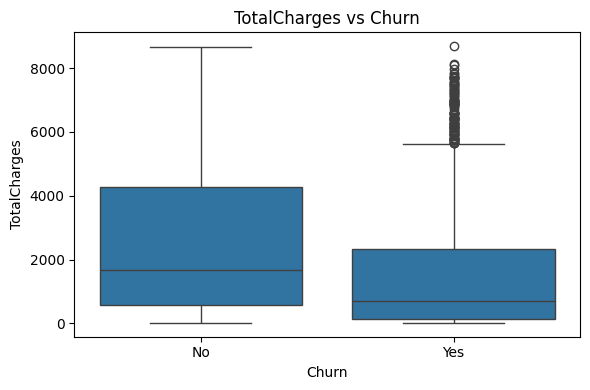

In [55]:
#Analysons maintenant la relation entre les variables numériques et la variable cible Churn
def plot_numeric_vs_churn(df, col):
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Churn", y=col)

    plt.title(f"{col} vs Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()
for col in num_cols:
    plot_numeric_vs_churn(df, col)


### Analyse de la corrélation entre les variables 

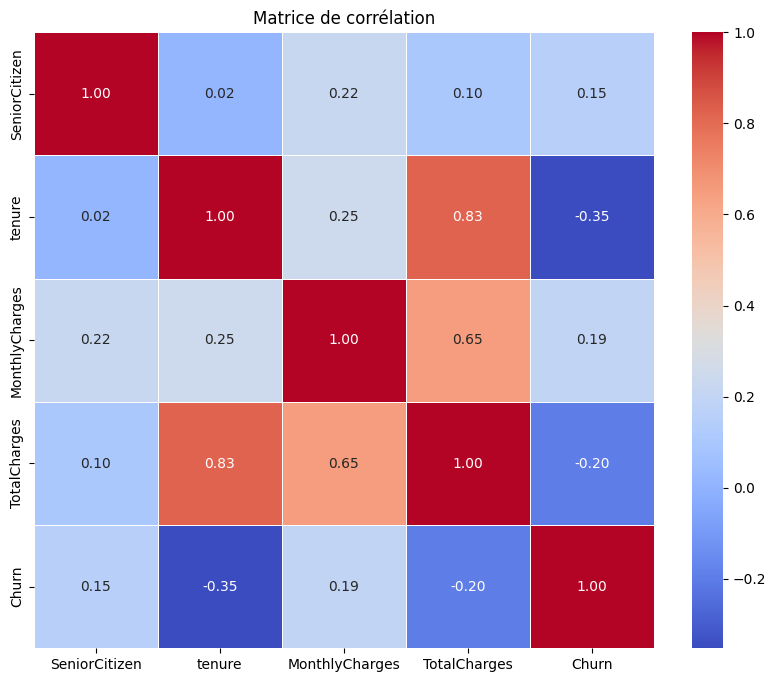

In [57]:
#Pour calculer la corrélation, nous devons d'abord convertir la variable cible Churn en format numérique (0 pour "No" et 1 pour "Yes").
df_corr = df.copy()
df_corr["Churn"] = df_corr["Churn"].map({"No": 0, "Yes": 1})
cols=list(num_cols) + ["Churn"]
corr_matrix = df_corr[cols].corr()
corr_matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation")
plt.show()

